In [1]:
#Library import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.linalg import qr, svd
from scipy.signal import welch, filtfilt, butter
import matplotlib
import scienceplots

In [2]:
#Definições para os gráficos
plt.style.use(['science', 'grid'])


LATEX_WIDTH = 6.29707

aspect_ratio = 6/8
scale = 1.0
FIG_WIDTH = LATEX_WIDTH * scale
FIG_HEIGHT = FIG_WIDTH * aspect_ratio
plt.rcParams['figure.figsize'] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["font.family"] = "serif"

metadata={
            'Creator' : 'Guilherme Zerwes',
            'Producer': 'Guilherme Zerwes',
            'CreationDate': None
        }

plt.rcParams['text.usetex'] = False

# matplotlib.use("pdf")

In [3]:
#Dataset import
files = sorted(os.listdir('../../Dataset/Treino dataset'), key=lambda x: int(x[5:-4]))

df = np.transpose(
      np.asarray(
            pd.read_table(
                os.path.join('..\..\Dataset\Treino dataset', files[0]), sep='\t', skiprows=10)))

t = df[0, :]
df = df[1:, :]

#Train-test split
train_test = 0.8 #train data
train = df[:, :int(train_test*df.shape[1])]
test = df[:, int(train_test*df.shape[1]):]

In [4]:
#Filtering
print('Filtering...')
filt_order = 2
filt_freq = 100

b, a = butter(filt_order, filt_freq, 'low', fs=1024)

for i in range(df.shape[0]):
        df[i,:] = filtfilt(b, a, df[i, :], padlen=150)


for l in range(len(files) - 1):
    print(files[l+1][:-4])
    fileName = os.path.join('..\..\Dataset\Treino dataset', files[l+1])

    #Loading the dataset
    df2 = np.transpose(
          np.asarray(pd.read_table(fileName, sep='\t', skiprows=10))[:, 1:])

    #Filtering the data with a order 2 lowpass filter at 80 Hz
    print('Filtering...')
    b, a = butter(filt_order, filt_freq, 'low', fs=1024)


    for i in range(df2.shape[0]):
        df2[i,:] = filtfilt(b, a, df2[i, :], padlen=150)

    # df = np.concatenate((df, df2), axis=1)
    train = np.concatenate((train, df2[:, :int(train_test*df.shape[1])]), axis=1)
    test = np.concatenate((test, df2[:, int(train_test*df.shape[1]):]), axis=1)
    print(train.shape)

Filtering...
zzzAD1
Filtering...
(30, 419430)
zzzAD2
Filtering...
(30, 629145)
zzzAD3
Filtering...
(30, 838860)
zzzAD4
Filtering...
(30, 1048575)
zzzAD5
Filtering...
(30, 1258290)
zzzAD6
Filtering...
(30, 1468005)
zzzAD7
Filtering...
(30, 1677720)
zzzAD8
Filtering...
(30, 1887435)
zzzAD9
Filtering...
(30, 2097150)
zzzAD10
Filtering...
(30, 2306865)
zzzAD11
Filtering...
(30, 2516580)
zzzAD12
Filtering...
(30, 2726295)
zzzAD13
Filtering...
(30, 2936010)
zzzAD14
Filtering...
(30, 3145725)
zzzAD15
Filtering...
(30, 3355440)
zzzAD16
Filtering...
(30, 3565155)
zzzAD17
Filtering...
(30, 3774870)
zzzAD18
Filtering...
(30, 3984585)
zzzAD19
Filtering...
(30, 4194300)
zzzAD20
Filtering...
(30, 4404015)
zzzAD21
Filtering...
(30, 4613730)
zzzAD22
Filtering...
(30, 4823445)
zzzAD23
Filtering...
(30, 5033160)
zzzAD24
Filtering...
(30, 5242875)
zzzAD25
Filtering...
(30, 5452590)
zzzAD26
Filtering...
(30, 5662305)
zzzAD27
Filtering...
(30, 5872020)
zzzAD28
Filtering...
(30, 6081735)
zzzAD29
Filtering..

In [5]:
#Performing the SVD
print('Performing SVD...')
Psi, S, V = svd(train, full_matrices=False)
print(Psi.shape, S.shape, V.shape, S)

#Visualize singular values x rank
# plt.plot(np.arange(0,len(S),1), S)
# plt.grid()
# plt.title('Singular Values x Rank')
# plt.xlabel('Rank number')
# plt.ylabel('Singular values')
# plt.legend()
# plt.show()

#Determining optimal hard threshold for singular values
beta = train.shape[0]/train.shape[1]
omega = 0.56*beta**3 - 0.95*beta**2 + 1.82*beta + 1.43

threshold_sv = omega*np.median(S)

print(S[S>=threshold_sv].shape)

#Reducing number of basis
rank = S[S >= threshold_sv].shape[0]
print(f'Rank {rank}')

Psi_r = Psi[:,0:rank]

Performing SVD...
(30, 30) (30,) (30, 6501165) [489.41372488 431.94706263 162.52928433 154.93050693 140.55991977
  91.04100763  86.8970413   81.80199926  72.15058097  62.16615683
  59.02137047  51.05020031  49.20864278  35.91188174  33.67563521
  26.82538633  23.77515931  21.76969087  20.30667958  19.44348182
  18.71259437  11.18579903   9.28893373   9.10569597   8.78997788
   7.85307569   7.59723856   6.90992639   6.14603181   5.64841351]
(13,)
Rank 13


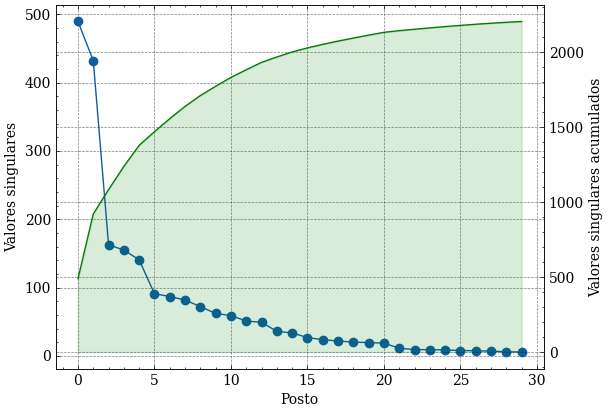

In [6]:
#Visualize singular values x rank
info = np.cumsum(S)

fig,ax = plt.subplots(1)

ax2 = ax.twinx()

# plt.title('Valores singulares x Posto da matriz')
ax2.plot(np.arange(0,len(S),1), info, c="g", label="Acumulado")
ax2.fill_between(np.arange(0,len(S),1),0,info, alpha=0.15, color="green")
ax.plot(np.arange(0,len(S),1), S, marker="o", label="Valores singulares")

ax.set_xlabel('Posto')
ax.set_ylabel('Valores singulares')
ax2.set_ylabel('Valores singulares acumulados')
# ax.legend()
plt.show()

fig.savefig('./Sing val x rank', bbox_inches='tight')


In [7]:
#Finding near-optimal sampling points
Q, R, pivots = qr(np.transpose(Psi_r), pivoting=True)

aux = int(rank - train.shape[0])
pivots = pivots[:aux]
print('Selected sensors: ', pivots)

#Fill in sampling matrix C
C = np.zeros((rank,df.shape[0]))

for i in range(rank):
        C[i,pivots[i]] = 1

#Defining the reconstruction operator
recon = np.dot(Psi_r,np.linalg.inv(np.dot(C,Psi_r)))

np.savetxt('./recon.txt',recon)
np.savetxt('./sensors.txt',pivots)

Selected sensors:  [ 7  5  9 24 11 28 26 20 13  3 16  1 18]


In [36]:
#Testing

#Sample the data
y = df2[pivots, int(train_test*df.shape[1]):]

#Reconstruct the data
x_hat = np.dot(recon,y)

## Frequency domain
nperseg_frf = len(t)//128
f, amp = welch(df2[10, int(train_test*df.shape[1]):], fs=1024.0, window='hann', nperseg=nperseg_frf)

f2, amp2 = welch(x_hat[10,:], fs=1024.0, window='hann', nperseg=nperseg_frf)

res = df2[10, int(train_test*df.shape[1]):] - x_hat[10,:]

## Histogram
from scipy.stats import gaussian_kde

density = gaussian_kde(res)
density.covariance_factor = lambda : .25
density._compute_covariance()

bin_edges = np.histogram_bin_edges(res, bins='auto')

# Autocorelation

#Não sei o que conlcuir disso??w
z95 = 1.96
ci_inf = np.mean(res) - z95*np.std(res)/np.sqrt(len(res))
ci_sup = np.mean(res) + z95*np.std(res)/np.sqrt(len(res))

#Metrics

r2_score = 1- np.sum((df2[10, int(train_test*df.shape[1]):] - x_hat[10,:])**2)/np.sum((df2[10, int(train_test*df.shape[1]):] - np.mean(df2[10,int(train_test*df.shape[1]):]))**2)
fro_norm = np.linalg.norm(df2[:, int(train_test*df.shape[1]):] - x_hat, 'fro')/np.linalg.norm(df2[:, int(train_test*df.shape[1]):],'fro')

print('R² score:', r2_score)
print('Norma de Frobenius:', fro_norm)


R² score: 0.9256998971994023
Norma de Frobenius: 0.10733232806803936


In [51]:

fig, ax = plt.subplots(2,1, figsize=(FIG_WIDTH,FIG_HEIGHT))
ax[0].plot(t[int(train_test*df.shape[1]):], df2[10, int(train_test*df.shape[1]):], label='Sinal original')
ax[0].plot(t[int(train_test*df.shape[1]):], x_hat[10, :], label='Sinal reconstruído')
ax[0].legend(ncols=2, loc=4)
ax[0].set_xlabel('Tempo (s)')
ax[0].set_ylabel('Aceleração (m/s²)')
ax[0].set_xlim([205,205.25])
ax[0].set_ylim([-0.085,0.065])
ax[0].set_title(f'a) Domínio do tempo')

ax[1].semilogy(f,abs(amp), label='Sinal original')
ax[1].semilogy(f,abs(amp2), label='Sinal reconstruído')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Amplitude')
ax[1].set_title(f'b) Domínio da frequência')
# plt.title(f'FRF Reconstruction comparison ({len(pivots)} sensors)')
# plt.grid()
ax[1].set_xlim([0,100])
ax[1].set_ylim([10**-10,10**-3])
ax[1].legend(ncols=1)

plt.tight_layout()
plt.show()

fig.savefig('./Comparação da reconstrução 13 sensores', bbox_inches='tight')

C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_2008\2093913228.py:23: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [54]:
#Evaluation

fig, ax = plt.subplots(2,1, figsize=(FIG_WIDTH,FIG_HEIGHT))

##Residue Scatter plot
ax[0].scatter(t[int(train_test*df.shape[1]):], res)
# ax[0].hlines(np.mean(res), xmin=0, xmax=255, color="r", linestyle="dashed")
# ax[0].hlines(np.mean(res) + np.std(res), xmin=0, xmax=255, linestyle="dashed")
# ax[0].hlines(np.mean(res) - np.std(res), xmin=0, xmax=255, linestyle="dashed")

ax[0].set_xlabel('Tempo (s)')
ax[0].set_ylabel('Aceleração (m/s²)')
ax[0].set_title(f'Gráfico de dispersão')
# ax[0].set_xlim([50,50.2])
ax[0].set_ylim([-0.04,0.04])


### Histogram

ax[1].hist(res, bins=bin_edges, alpha=0.3, density=True)
ax[1].plot(bin_edges, density(bin_edges), color="blue")
# ax[1].vlines(np.mean(res), ymin=0, ymax=50)
ax[1].set_xlabel('Aceleração (m/s²)')
ax[1].set_ylabel('Frequência')
ax[1].set_title(f'Histograma')
ax[1].set_xlim([-0.035,0.035])
# ax[1].set_ylim([0,45])
plt.show()
plt.tight_layout()


fig.savefig('./Histograma e dispersao', bbox_inches='tight')


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_2008\4192771204.py:28: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [ ]:
#Evaluation
##Auto-corelation residue plot

fig, ax = plt.subplots(1)
ax.acorr(res, maxlags=50)
ax.set_xlabel('Atrasos temporais (s)')
ax.set_ylabel('Correlação')
# plt.title(f'Comparação do resíduo da reconstrução com {len(pivots)} sensores')
plt.show()
plt.tight_layout()

fig.savefig('./Autocorrelação', bbox_inches='tight')


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_2008\4261190840.py:9: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [29]:
# #Posição dos sensores

r = 6
c = 5

sensx = [int(i+1) for i in range(c)]*r
sensy = [i + 1 for i in range(r) for j in range(c)]


grid = np.arange(0,30,1).reshape((6,5))
index = np.zeros((pivots.shape[0], 2))

for i in range(len(pivots)):
    index[i,1] = np.where(grid == pivots[i])[0]
    index[i,0] = np.where(grid == pivots[i])[1]


fig, ax = plt.subplots(1)

ax.scatter(sensx, sensy)
ax.scatter(index[:,0]+1, index[:,1]+1, s=450, marker='s', facecolors='none', edgecolors='r')
ax.hlines([1,2,3,4,5,6],1,5)
ax.vlines([1,2,3,4,5], 1,6)
ax.grid()
plt.gca().invert_yaxis()
plt.show()
fig.savefig('./Posicao dos sensores', bbox_inches='tight')



C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_2008\404781582.py:26: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [30]:
#Métricas numéricas
#R² médio ao longo de todos os cenários de dano
aux = int(df.shape[1]*(1-train_test))
r2 = np.zeros(len(files))
frob = np.zeros_like(r2)
rmse = np.zeros_like(r2)

for l in range(len(files)):
    print(files[l][:-4])
    fileName = os.path.join('..\..\Dataset\Treino dataset', files[l])

    #Loading the dataset
    df2 = np.transpose(
          np.asarray(pd.read_table(fileName, sep='\t', skiprows=10))[:, 1:])

    #Filtering the data with a order 2 lowpass filter at 80 Hz
    print('Filtering...')
    b, a = butter(filt_order, filt_freq, 'low', fs=1024)


    for i in range(df2.shape[0]):
        df2[i,:] = filtfilt(b, a, df2[i, :], padlen=150)

    test = df2[:, int(train_test*df.shape[1]):]
    
    x_hat = np.dot(recon,test[pivots,:])

    r2_score = 0
    rmse_i = 0

    for i in range(test.shape[0]):
        u = np.sum((test[i,:] - x_hat[i,:])**2)
        v = np.sum((test[i,:] - np.mean(df2[i,:]))**2)
        r2_score += 1 - u/v
        rmse_i += np.sqrt(u/test.shape[1])

    w = np.linalg.norm(test[:,:] - x_hat, 'fro')
    z = np.linalg.norm(test[:,:],'fro')
    
    frob[l] = w/z
    r2[l] = r2_score/test.shape[0]
    rmse[l] = rmse_i/test.shape[0]
    print(r2[l], rmse[l])

zzzAA0
Filtering...
0.9805502620367174 0.004933071950761286
zzzAD1
Filtering...
0.9662197912157906 0.005260555103955778
zzzAD2
Filtering...
0.9843288346607163 0.004380387985363433
zzzAD3
Filtering...
0.9747637596318569 0.004956078803864333
zzzAD4
Filtering...
0.9764856499159467 0.004593131606739012
zzzAD5
Filtering...
0.9615687366133628 0.005950514014679994
zzzAD6
Filtering...
0.9689631181464683 0.005011096100703118
zzzAD7
Filtering...
0.9612992629127189 0.005760234971469723
zzzAD8
Filtering...
0.9733409380889415 0.00532792249428513
zzzAD9
Filtering...
0.9641077987962442 0.005809969096554925
zzzAD10
Filtering...
0.9659325770510416 0.005508139828706461
zzzAD11
Filtering...
0.9806871227480117 0.00530362149367722
zzzAD12
Filtering...
0.969127918429943 0.005294084398763762
zzzAD13
Filtering...
0.9771054221626428 0.004956704566223365
zzzAD14
Filtering...
0.9689609491268859 0.005381321287589863
zzzAD15
Filtering...
0.9728147815804643 0.005066361788819732
zzzAD16
Filtering...
0.94891745695640

In [31]:
print(np.max(r2))

0.9857247005255761


In [35]:
fig,ax = plt.subplots(1)

ax2 = ax.twinx()
ax.bar(np.arange(0,31,1), r2)
ax2.plot(np.arange(0,31,1), rmse, color='green', marker='s')
ax.set_xlabel('Cenário de dano')
ax.set_ylabel('Coeficiente de determinação')
ax2.set_ylabel('Raiz do erro quadrático médio (m/s²)')
ax.set_ylim([0.9,1])
ax2.set_ylim([0,0.0075])

fig.tight_layout()
plt.show()
fig.savefig('./R2', bbox_inches='tight')


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_2008\2215756501.py:13: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()
